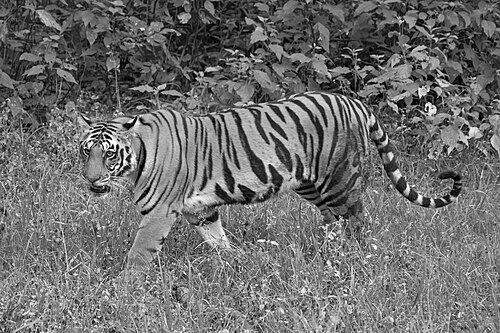

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/Tiger.jpg")
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(img)

array([[  0, 255,   0, ..., 255,   0,   0],
       [  0, 255,   0, ...,   0,   0,   0],
       [255,   0, 255, ...,   0, 255, 255],
       ...,
       [255,   0, 255, ...,   0,   0,   0],
       [255,   0,   0, ...,   0,   0,   0],
       [255,   0, 255, ..., 255, 255,   0]], dtype=uint8)
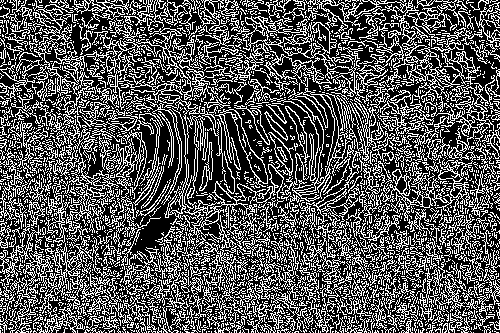

In [ ]:
canny = cv2.Canny(img,threshold1=100,threshold2=200)
canny


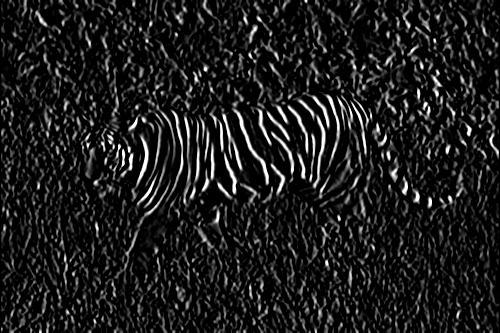

In [ ]:
img = cv2.GaussianBlur(img,(3,3),0)
sobel = cv2.Sobel(img,cv2.CV_64F,1,0)
cv2_imshow(sobel)

In [ ]:
def convolution(img,kernel):
  output = np.zeros(img.shape)
  ker_size = kernel.shape[0]
  pad = int(ker_size/2)
  for i in range(1,img.shape[0]-1):
    for j in range(1,img.shape[1]-1):
      region = img[i-pad:i+pad+1,j-pad:j+pad+1]
      val = np.sum(region*kernel)
      output[i,j] = val
  return output

In [ ]:
blur_ker = np.array([
    [1,2,1],
    [2,4,2],
    [1,2,1]
])/16

vert_edge_ker = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

horz_edge_ker = np.array([
    [-1,-2,-1],
    [0,0,0],
    [1,2,1]
])

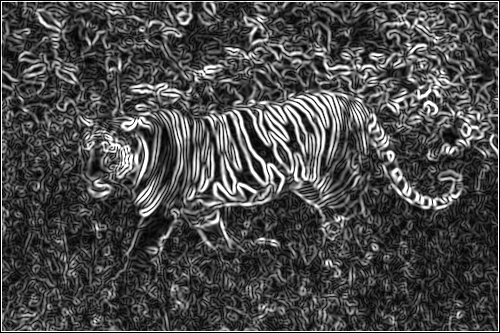

In [29]:
blur = convolution(img,blur_ker)
vert_edge = convolution(blur,vert_edge_ker)
horz_edge = convolution(blur,horz_edge_ker)
result = np.sqrt((vert_edge**2) + (horz_edge**2))
cv2_imshow(result)

In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers,datasets
from google.colab.patches import cv2_imshow
import numpy as np

(x_train,y_train),(x_test,y_test) = datasets.mnist.load_data()

x_train=x_train/255
x_test=x_test/255

print(x_train.shape,x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [3]:
x_train = x_train[... , None]
x_test = x_test[... , None]
print(x_train.shape,x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


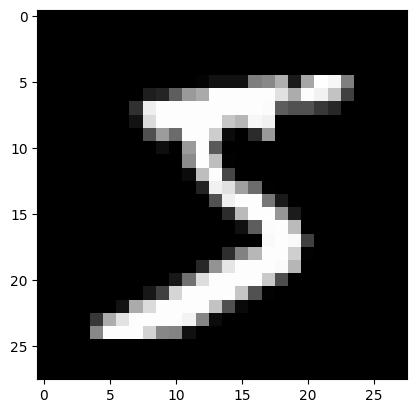

5


In [10]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0],cmap = "gray")
plt.show()
print(y_train[0])

In [12]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape = (28,28,1)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu",input_shape = (28,28,1)),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation = "softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer="adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

CIFAR-10

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets,models,layers
import numpy as np
import matplotlib.pyplot as plt

(x_train,y_train),(x_test,y_test)= datasets.cifar10.load_data()
print(x_train.shape,x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1612s 9us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


In [3]:
x_train =x_train/255
x_test = x_test/255
print(x_train.shape,x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


In [54]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [78]:
model = models.Sequential([
    layers.Conv2D(16,(3,3),activation="relu",input_shape = (32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPool2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64,(3,3),activation="relu",input_shape = (32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPool2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(128,(3,3),activation="relu",input_shape = (32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPool2D((2,2)),
    layers.BatchNormalization(),
    layers.Flatten(),

    layers.Dense(256,activation="relu"),
    layers.Dense(10,activation = "softmax")
])

In [79]:
model.compile(
    optimizer="adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

In [80]:
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.5520 - loss: 1.2760 - val_accuracy: 0.5966 - val_loss: 1.2129
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6884 - loss: 0.8893 - val_accuracy: 0.6497 - val_loss: 0.9869
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7472 - loss: 0.7283 - val_accuracy: 0.7078 - val_loss: 0.8648
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7862 - loss: 0.6103 - val_accuracy: 0.7048 - val_loss: 0.8810
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8231 - loss: 0.5061 - val_accuracy: 0.7177 - val_loss: 0.8814


In [81]:
y_pred = model.predict(x_test)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


array([0.12767018, 0.00894331, 0.07798203, 0.36300048, 0.00322082,
       0.10795209, 0.08470843, 0.00927396, 0.04029555, 0.17695312],
      dtype=float32)

In [102]:
y_predictions = []
for i in y_pred:
  val = np.argmax(i)
  y_predictions.append(val)
y_predictions[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [83]:
y_testing =y_test.reshape(-1,)
y_testing

array([3, 8, 8, ..., 5, 1, 7], dtype=uint8)

In [84]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_predictions,y_testing)
acc

0.7177

DENSENET

In [86]:
import torch
from torchvision import datasets, models, transforms
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [87]:
import torchvision
torchvision.__version__

'0.26.0+cu128'

In [88]:
model = models.resnet50(pretrained=True).to(device)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
               nn.Linear(2048, 128),
               nn.ReLU(inplace=True),
               nn.Linear(128, 2)).to(device)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.0MB/s]


In [89]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters())

In [94]:
from tensorflow.keras.applications import DenseNet121
densenet = DenseNet121(
    weights='/content/DenseNet-BC-121-32-no-top.h5',
    include_top=False,
    input_shape=(32,32,3)
)

In [96]:
from tensorflow.keras.models import Sequential
model = Sequential()
model.add(densenet)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(14, activation='softmax'))

In [97]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1, 1, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 14)             │        14,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,051,854 (26.90 MB)

 Trainable params: 6,968,206 (26.58 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [99]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# checkpoint = ModelCheckpoint(
#     'model.h5',
#     monitor='val_acc',
#     verbose=1,
#     save_best_only=True,
#     save_weights_only=False,
#     mode='auto'
# )

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=7,
    validation_split=0.1
)

Epoch 1/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 288s 198ms/step - accuracy: 0.6906 - loss: 0.9221 - val_accuracy: 0.7272 - val_loss: 0.8498
Epoch 2/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7372 - loss: 0.7810 - val_accuracy: 0.6918 - val_loss: 0.9370
Epoch 3/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.8012 - loss: 0.5936 - val_accuracy: 0.1092 - val_loss: 138.5789
Epoch 4/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7658 - loss: 0.7017 - val_accuracy: 0.7746 - val_loss: 0.6711
Epoch 5/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8075 - loss: 0.5764 - val_accuracy: 0.0980 - val_loss: 64.8718
Epoch 6/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.7132 - loss: 0.8659 - val_accuracy: 0.7942 - val_loss: 0.6082
Epoch 7/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.8395 - loss: 0.4660 - val_accuracy: 0.8196 - val_loss: 0.5366


In [100]:
y_pred = model.predict(x_test)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step


array([2.7263071e-04, 1.5891371e-04, 3.8244299e-04, 9.8105329e-01,
       3.4190988e-04, 1.2033232e-02, 4.9058814e-03, 1.7789261e-04,
       6.4186897e-04, 3.1924697e-05, 1.5161584e-08, 2.8557801e-08,
       7.6054514e-09, 3.2952691e-08], dtype=float32)

In [103]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_predictions,y_testing)
acc

0.8138